# 02 — Exploratory Data Analysis
## Anime Streaming Platform Analytics

With the data cleaned and verified (`01_data_cleaning.ipynb`), we explore it the
way an analyst preparing for a product review would: **every chart answers a
stakeholder question and ends in a takeaway**, not just a picture.

**Sections**
1. Platform growth — are we growing, and is the growth healthy?
2. Audience — who watches, where, in what language?
3. Content — what earns the watch hours, and what should we license more of?
4. Viewing behaviour — when, on what device, and how intensely?
5. Experience quality — does buffering actually cost us satisfaction?
6. Retention & churn — who leaves, when, and why?
7. What moves together — correlation view

*Charts use a colorblind-validated palette; rankings use a single hue (identity
belongs to the axis, not the colors); plans keep fixed colors everywhere.*

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ---- palette (validated categorical order + chrome inks) ----
CAT = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
BLUE = CAT[0]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#3987e5", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#1c5cab", "#f0efec", "#b23636"])
PLAN_ORDER = ["Free", "Basic", "Premium", "Family"]
PLAN_COLORS = {"Free": MUTED, "Basic": BLUE, "Premium": "#4a3aa7", "Family": "#008300"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "font.family": "Segoe UI", "text.color": INK, "axes.edgecolor": BASE,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})


def style(ax, ygrid_only=True, pct=False):
    """Recessive chrome: hairline grid on the value axis only."""
    ax.grid(axis="y" if ygrid_only else "x")
    if pct:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))


def ranked_hbar(s: pd.Series, title: str, xlabel: str, fmt="{:,.0f}", figsize=(9, 4.6)):
    """Ranking chart: horizontal bars, one hue, largest on top, labelled ends."""
    fig, ax = plt.subplots(figsize=figsize)
    s = s.sort_values()
    ax.barh(s.index.astype(str), s.values, color=BLUE, height=0.62)
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in s.values],
                 padding=4, color=INK2, fontsize=9)
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.margins(x=0.10)
    style(ax, ygrid_only=False)
    plt.tight_layout()
    plt.show()


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
P = PROJECT_ROOT / "data" / "processed"

events = pd.read_csv(P / "anime_streaming_clean.csv",
                     parse_dates=["Watch_Date", "Subscription_Start_Date", "Subscription_End_Date"])
subs = pd.read_csv(P / "fact_subscriptions.csv",
                   parse_dates=["Subscription_Start_Date", "Subscription_End_Date"])
users = pd.read_csv(P / "dim_user.csv").merge(
    subs.drop(columns=["Subscription_Plan", "Subscription_Status"]), on="User_ID")
events["Month"] = events["Watch_Date"].dt.to_period("M").dt.to_timestamp()
print(f"{len(events):,} watch events | {len(users):,} users | "
      f"{events['Watch_Date'].min():%Y-%m-%d} to {events['Watch_Date'].max():%Y-%m-%d}")

41,046 watch events | 7,993 users | 2023-01-27 to 2026-06-29


## 1. Platform growth

The first thing any executive asks: *are we growing?* We look at acquisition
(sign-ups), attrition (cancellations), the resulting subscriber base, and
monthly recurring revenue (MRR). Because we have start and end dates per user,
we can reconstruct the *active* base for any month — a much stronger metric
than raw sign-ups.

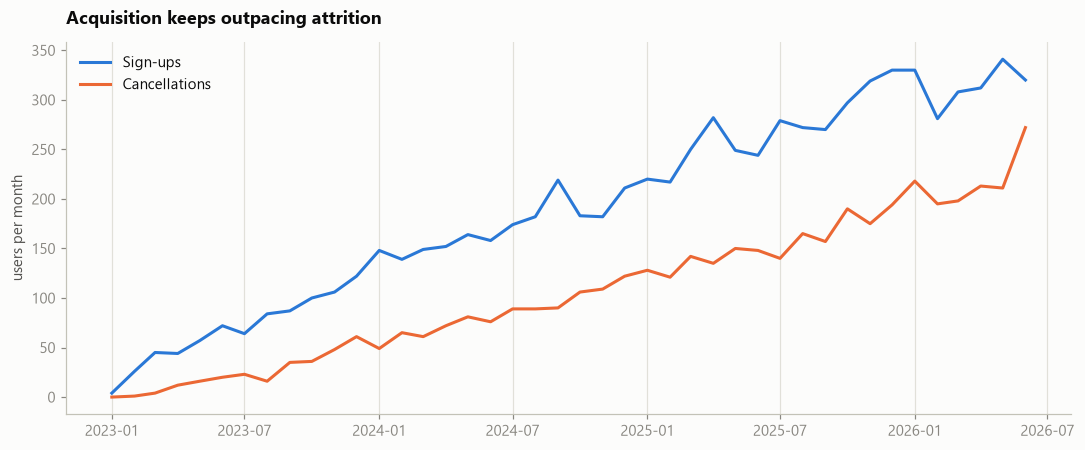

In [2]:
months = pd.period_range("2023-01", "2026-06", freq="M")
signups = subs["Subscription_Start_Date"].dt.to_period("M").value_counts().reindex(months, fill_value=0)
cancels = (subs.loc[subs["Subscription_End_Date"].notna(), "Subscription_End_Date"]
           .dt.to_period("M").value_counts().reindex(months, fill_value=0))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(months.to_timestamp(), signups.values, color=CAT[0], lw=2, label="Sign-ups")
ax.plot(months.to_timestamp(), cancels.values, color=CAT[5], lw=2, label="Cancellations")
ax.set_title("Acquisition keeps outpacing attrition", pad=12)
ax.set_ylabel("users per month")
ax.legend(loc="upper left")
style(ax)
plt.tight_layout(); plt.show()

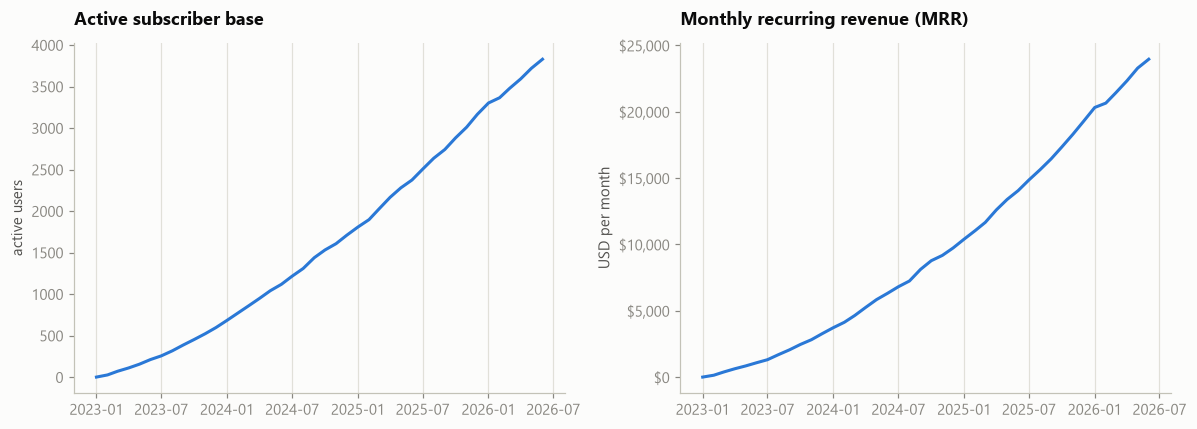

Year-end active users: {2023: 600, 2024: 1713, 2025: 3169, 2026: 3832}
MRR June 2026: $23,959


In [3]:
active_base, mrr = [], []
for m in months:
    active = ((subs["Subscription_Start_Date"] <= m.end_time)
              & (subs["Subscription_End_Date"].isna()
                 | (subs["Subscription_End_Date"] >= m.start_time)))
    active_base.append(int(active.sum()))
    mrr.append(subs.loc[active, "Monthly_Fee"].sum())
growth = pd.DataFrame({"Month": months.to_timestamp(), "Active_Users": active_base, "MRR": mrr})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(growth["Month"], growth["Active_Users"], color=BLUE, lw=2)
axes[0].set_title("Active subscriber base", pad=12)
axes[0].set_ylabel("active users")
axes[1].plot(growth["Month"], growth["MRR"], color=BLUE, lw=2)
axes[1].set_title("Monthly recurring revenue (MRR)", pad=12)
axes[1].set_ylabel("USD per month")
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
for ax in axes:
    style(ax)
plt.tight_layout(); plt.show()

yoy = growth.set_index("Month").resample("YE").last()
print("Year-end active users:", dict(zip(yoy.index.year, yoy["Active_Users"])))
print(f"MRR June 2026: ${growth['MRR'].iloc[-1]:,.0f}")

**Takeaway.** The platform is in a healthy growth phase: sign-ups exceed
cancellations in essentially every month, so the active base and MRR climb
steadily across the whole window. But cancellations grow *with* the base — the
retention work in section 6 is what protects this curve, not more acquisition.

## 2. Audience — who watches?

Demographics decide content licensing, dubbing budgets, and ad targeting. We
profile age, market, plan mix, and audio-language preference.

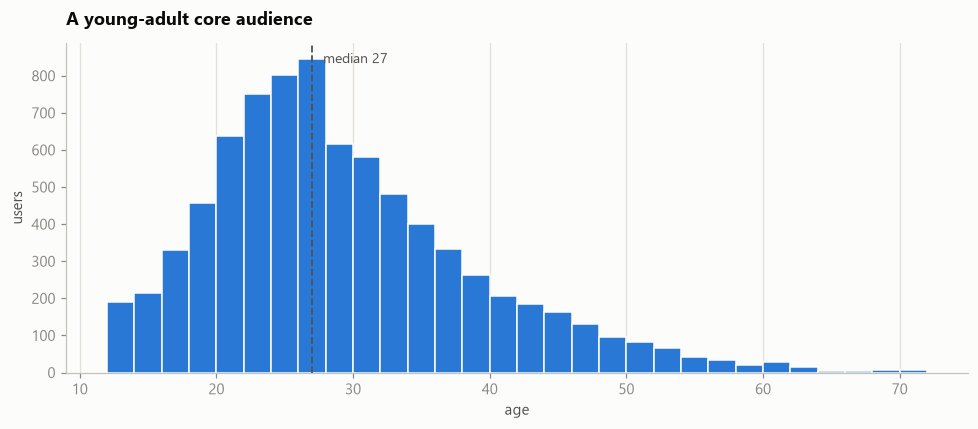

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(users["Age"], bins=range(12, 74, 2), color=BLUE, edgecolor=SURFACE, linewidth=1)
med = users["Age"].median()
ax.axvline(med, color=INK2, lw=1.2, ls="--")
ax.text(med + 0.8, ax.get_ylim()[1] * 0.94, f"median {med:.0f}", color=INK2, fontsize=9)
ax.set_title("A young-adult core audience", pad=12)
ax.set_xlabel("age"); ax.set_ylabel("users")
style(ax)
plt.tight_layout(); plt.show()

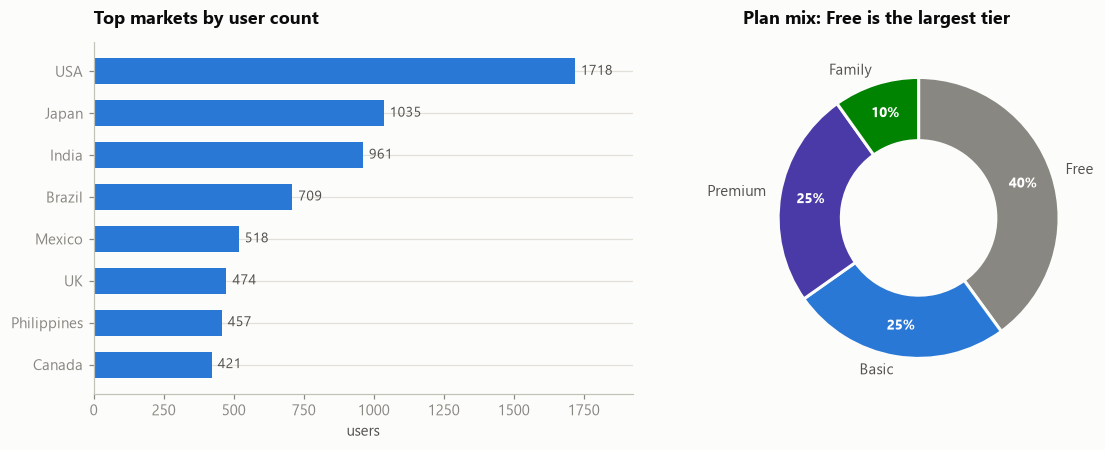

Watch time by audio language (share):
Language
Japanese      51.9%
English       28.8%
Portuguese     5.7%
Spanish        4.2%
Hindi          3.1%
German         2.7%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

top_countries = users["Country"].value_counts().head(8).sort_values()
axes[0].barh(top_countries.index, top_countries.values, color=BLUE, height=0.62)
axes[0].bar_label(axes[0].containers[0], padding=4, color=INK2, fontsize=9)
axes[0].set_title("Top markets by user count", pad=12)
axes[0].set_xlabel("users"); axes[0].margins(x=0.12)
style(axes[0], ygrid_only=False)

plan_mix = users["Subscription_Plan"].value_counts().reindex(PLAN_ORDER)
_, _, autotexts = axes[1].pie(
    plan_mix, labels=plan_mix.index, colors=[PLAN_COLORS[p] for p in PLAN_ORDER],
    autopct="%1.0f%%", pctdistance=0.78, startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor=SURFACE, linewidth=2),
    textprops=dict(color=INK2, fontsize=10))
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold"); t.set_fontsize(9)
axes[1].set_title("Plan mix: Free is the largest tier", pad=12)
plt.tight_layout(); plt.show()

lang = events.groupby("Language")["Watch_Time_Minutes"].sum()
print("Watch time by audio language (share):")
print((lang / lang.sum()).sort_values(ascending=False).map("{:.1%}".format).head(6).to_string())

**Takeaway.** The core is 18–34 with a median in the mid-20s — a demographic
that expects mobile-first UX and social features. The US, Japan and India lead
on headcount, but the Free tier is the largest single group (~40% of users):
the biggest commercial opportunity in this dataset is Free→paid conversion,
not new-market acquisition. Japanese-audio (subtitled) viewing dominates watch time, so sub
availability at simulcast time matters more than dub breadth.

## 3. Content — what earns the watch hours?

Licensing is the biggest cost line for a streaming platform. Watch hours tell
us what to renew; completion tells us what *holds* attention; ratings tell us
what builds the brand. These three do not always agree — which is exactly why
we look at all three.

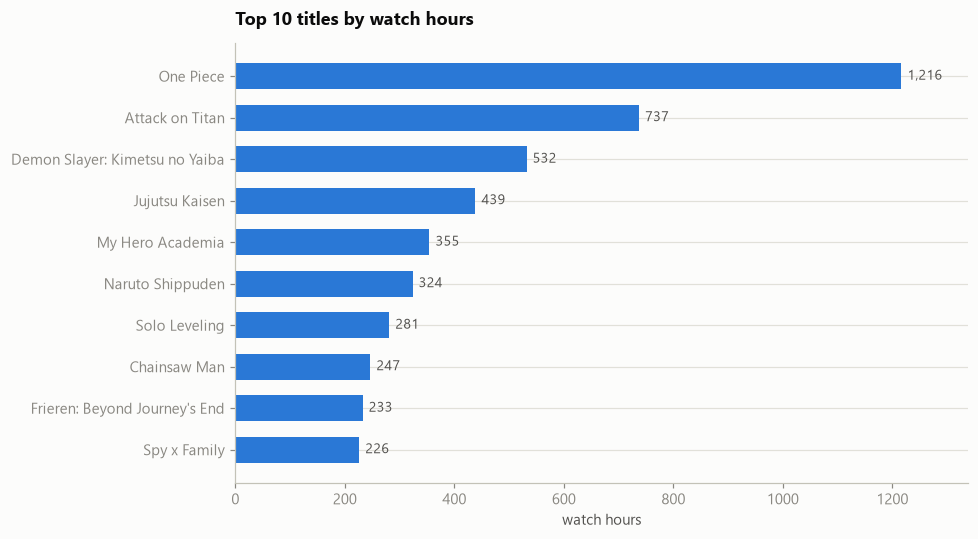

In [6]:
watch_h = events.groupby("Anime_Title")["Watch_Time_Minutes"].sum().div(60)
ranked_hbar(watch_h.nlargest(10), "Top 10 titles by watch hours", "watch hours", figsize=(9, 5))

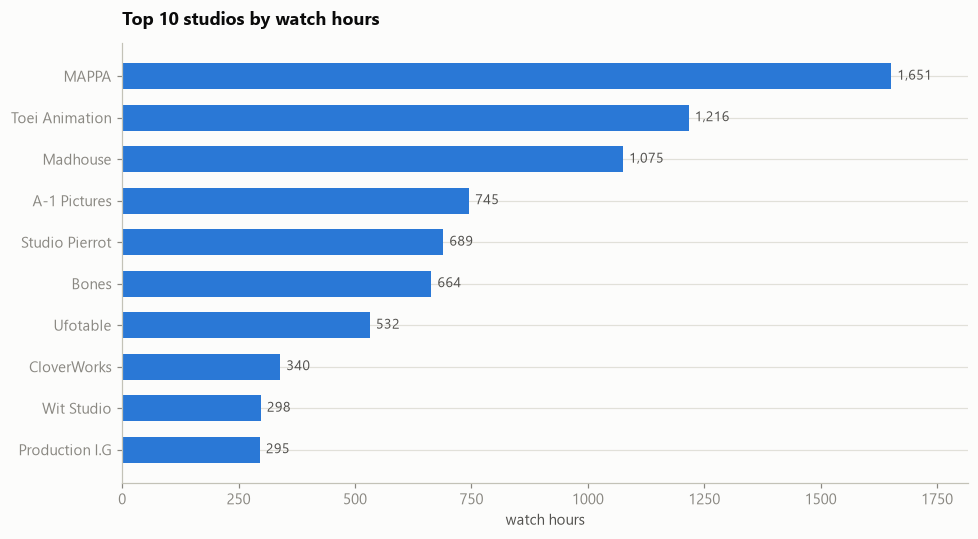

In [7]:
studio_h = events.groupby("Studio")["Watch_Time_Minutes"].sum().div(60)
ranked_hbar(studio_h.nlargest(10), "Top 10 studios by watch hours", "watch hours", figsize=(9, 5))

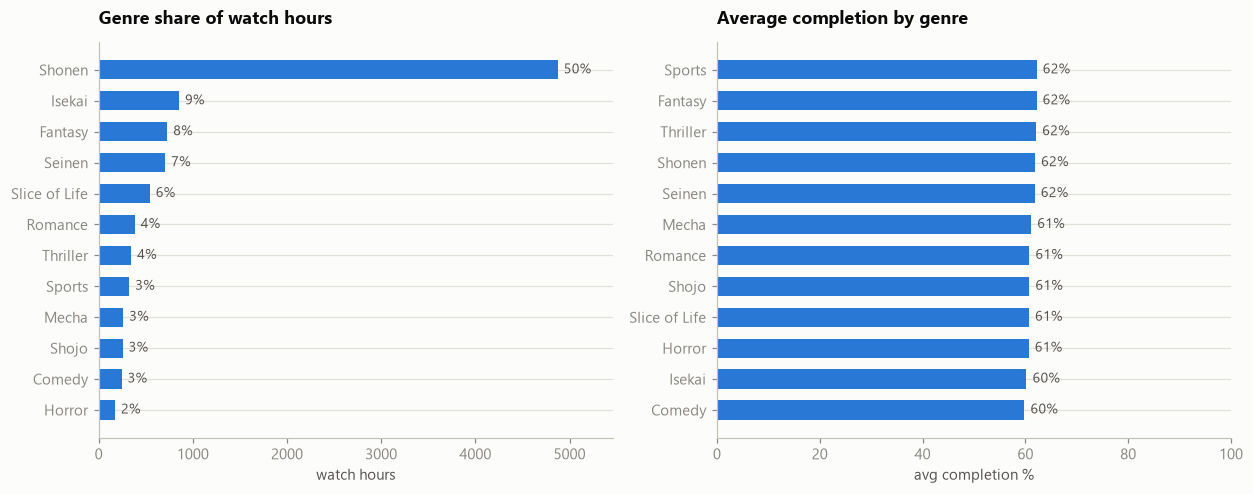

In [8]:
genre = events.groupby("Genre").agg(hours=("Watch_Time_Minutes", lambda s: s.sum() / 60),
                                    completion=("Completion_Percentage", "mean"))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

g = genre["hours"].sort_values()
axes[0].barh(g.index, g.values, color=BLUE, height=0.62)
axes[0].bar_label(axes[0].containers[0],
                  labels=[f"{v / g.sum():.0%}" for v in g.values], padding=4, color=INK2, fontsize=9)
axes[0].set_title("Genre share of watch hours", pad=12)
axes[0].set_xlabel("watch hours"); axes[0].margins(x=0.12)
style(axes[0], ygrid_only=False)

c = genre["completion"].sort_values()
axes[1].barh(c.index, c.values, color=BLUE, height=0.62)
axes[1].bar_label(axes[1].containers[0],
                  labels=[f"{v:.0f}%" for v in c.values], padding=4, color=INK2, fontsize=9)
axes[1].set_title("Average completion by genre", pad=12)
axes[1].set_xlabel("avg completion %"); axes[1].set_xlim(0, 100)
style(axes[1], ygrid_only=False)
plt.tight_layout(); plt.show()

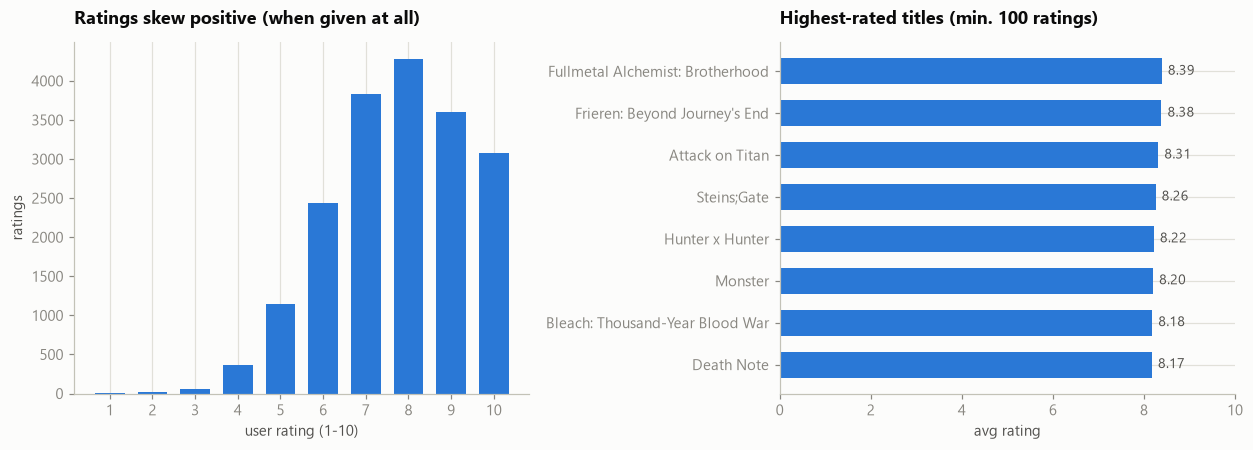

Share of events with a rating: 46%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ratings = events["User_Rating"].dropna().astype(int).value_counts().sort_index()
axes[0].bar(ratings.index, ratings.values, color=BLUE, width=0.7)
axes[0].set_title("Ratings skew positive (when given at all)", pad=12)
axes[0].set_xlabel("user rating (1-10)"); axes[0].set_ylabel("ratings")
axes[0].set_xticks(range(1, 11))
style(axes[0])

rated = events.dropna(subset=["User_Rating"]).groupby("Anime_Title")["User_Rating"]
top_rated = rated.mean()[rated.count() >= 100].nlargest(8).sort_values()
axes[1].barh(top_rated.index, top_rated.values, color=BLUE, height=0.62)
axes[1].bar_label(axes[1].containers[0],
                  labels=[f"{v:.2f}" for v in top_rated.values], padding=4, color=INK2, fontsize=9)
axes[1].set_title("Highest-rated titles (min. 100 ratings)", pad=12)
axes[1].set_xlabel("avg rating"); axes[1].set_xlim(0, 10); axes[1].margins(x=0.1)
style(axes[1], ygrid_only=False)
plt.tight_layout(); plt.show()

print(f"Share of events with a rating: {events['User_Rating'].notna().mean():.0%}")

**Takeaway.** Shonen alone is roughly half of all watch hours and the top-10
title list is dominated by it — renewals there are non-negotiable. But
completion is strikingly *flat across genres* (roughly 60–65% everywhere): niche
genres hold viewers just as well once they press play, so their smaller hours
reflect discovery, not quality. That makes targeted recommendation (surfacing
Thriller/Sports to the right users) cheaper than licensing more of the same.
Ratings are given on under half of views (~45%) and skew 7–9, so *rating count*
matters as much as rating average when comparing titles.

## 4. Viewing behaviour — when and how people watch

Release scheduling, ad load, and infrastructure capacity all depend on *when*
viewing happens and *how intense* it is.

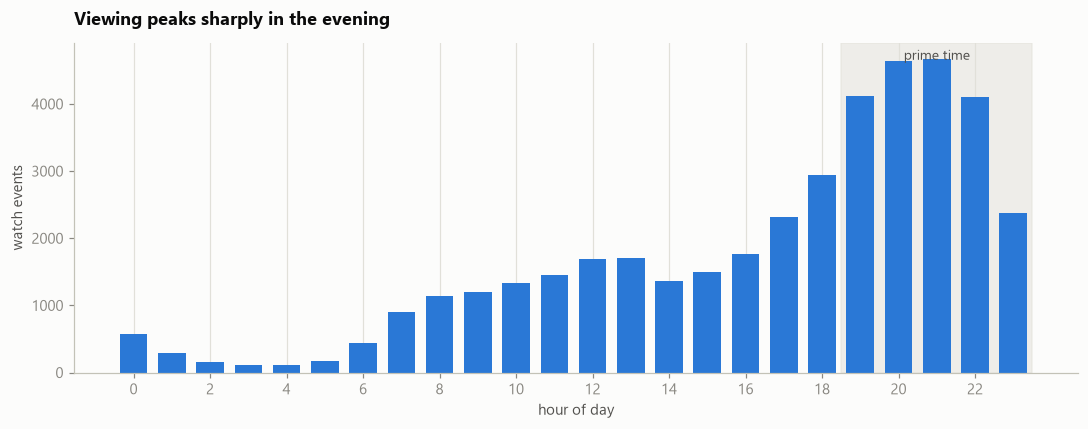

19:00-23:00 carries 48% of all viewing


In [10]:
hourly = events["Watch_Hour"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values, color=BLUE, width=0.72)
ax.axvspan(18.5, 23.5, color=GRID, alpha=0.5, zorder=0)
ax.text(21, ax.get_ylim()[1] * 0.95, "prime time", ha="center", color=INK2, fontsize=9)
ax.set_title("Viewing peaks sharply in the evening", pad=12)
ax.set_xlabel("hour of day"); ax.set_ylabel("watch events")
ax.set_xticks(range(0, 24, 2))
style(ax)
plt.tight_layout(); plt.show()
print(f"19:00-23:00 carries {events['Peak_Hour'].mean():.0%} of all viewing")

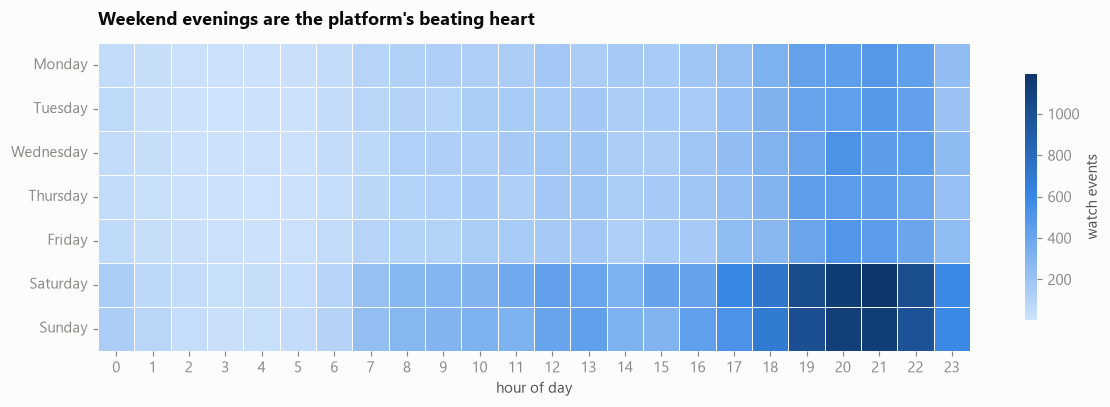

Weekend share of events: 49% (uniform would be 29%)


In [11]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = (events.assign(Day=events["Watch_Date"].dt.day_name())
        .pivot_table(index="Day", columns="Watch_Hour", values="Event_ID", aggfunc="count")
        .reindex(day_order))
fig, ax = plt.subplots(figsize=(11, 3.8))
sns.heatmap(heat, cmap=SEQ, ax=ax, cbar_kws={"label": "watch events", "shrink": 0.8},
            linewidths=0.5, linecolor=SURFACE)
ax.set_title("Weekend evenings are the platform's beating heart", pad=12)
ax.set_xlabel("hour of day"); ax.set_ylabel("")
ax.grid(False)
plt.tight_layout(); plt.show()
print(f"Weekend share of events: {events['Weekend_Viewing'].mean():.0%} (uniform would be 29%)")

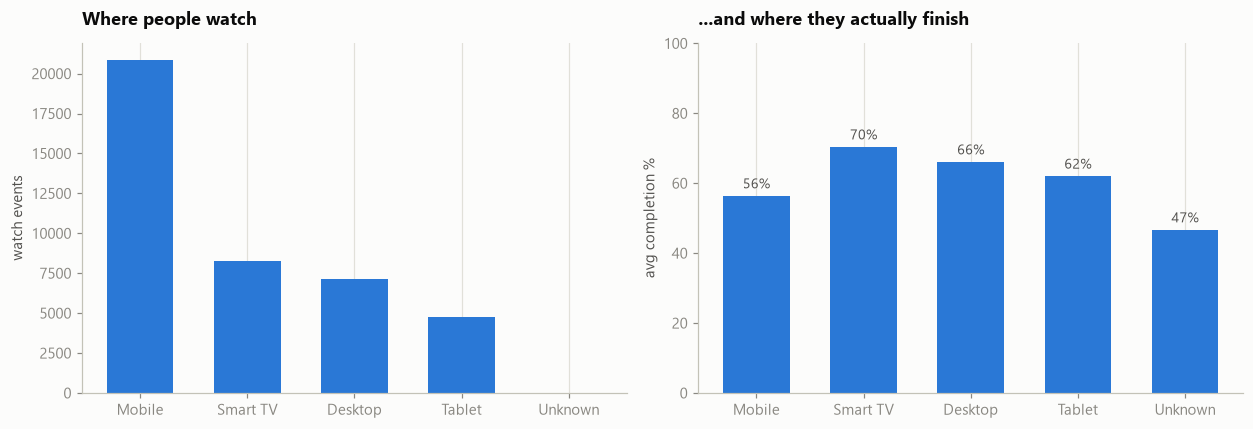

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

dev = events["Device"].value_counts()
axes[0].bar(dev.index, dev.values, color=BLUE, width=0.62)
axes[0].set_title("Where people watch", pad=12)
axes[0].set_ylabel("watch events")
style(axes[0])

comp = events.groupby("Device")["Completion_Percentage"].mean().reindex(dev.index)
axes[1].bar(comp.index, comp.values, color=BLUE, width=0.62)
axes[1].bar_label(axes[1].containers[0], labels=[f"{v:.0f}%" for v in comp.values],
                  padding=3, color=INK2, fontsize=9)
axes[1].set_title("...and where they actually finish", pad=12)
axes[1].set_ylabel("avg completion %"); axes[1].set_ylim(0, 100)
style(axes[1])
plt.tight_layout(); plt.show()

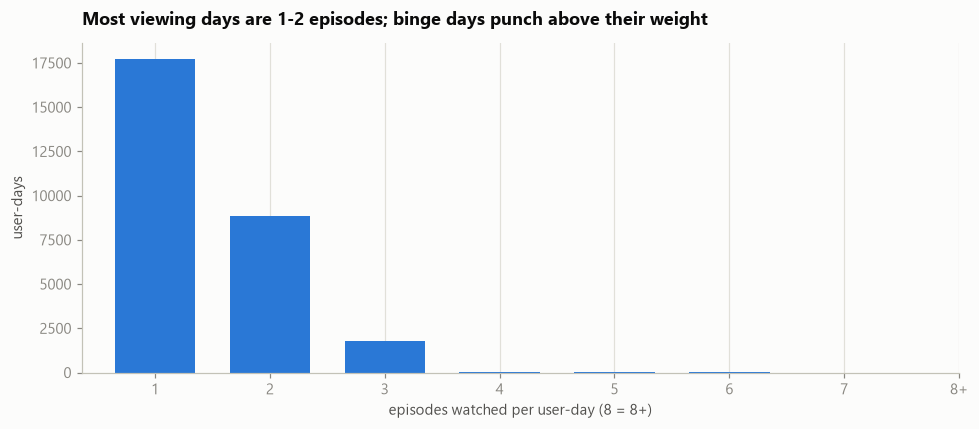

Binge days (3+ episodes): 6% of user-days, 14% of all episode views


In [13]:
per_day = events.groupby(["User_ID", events["Watch_Date"].dt.date]).size()
binge = per_day.clip(upper=8).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(binge.index.astype(int), binge.values, color=BLUE, width=0.7)
ax.set_title("Most viewing days are 1-2 episodes; binge days punch above their weight", pad=12)
ax.set_xlabel("episodes watched per user-day (8 = 8+)"); ax.set_ylabel("user-days")
ax.set_xticks(range(1, 9), [*map(str, range(1, 8)), "8+"])
style(ax)
plt.tight_layout(); plt.show()
binge_days = (per_day >= 3)
print(f"Binge days (3+ episodes): {binge_days.mean():.0%} of user-days, "
      f"{per_day[binge_days].sum() / per_day.sum():.0%} of all episode views")

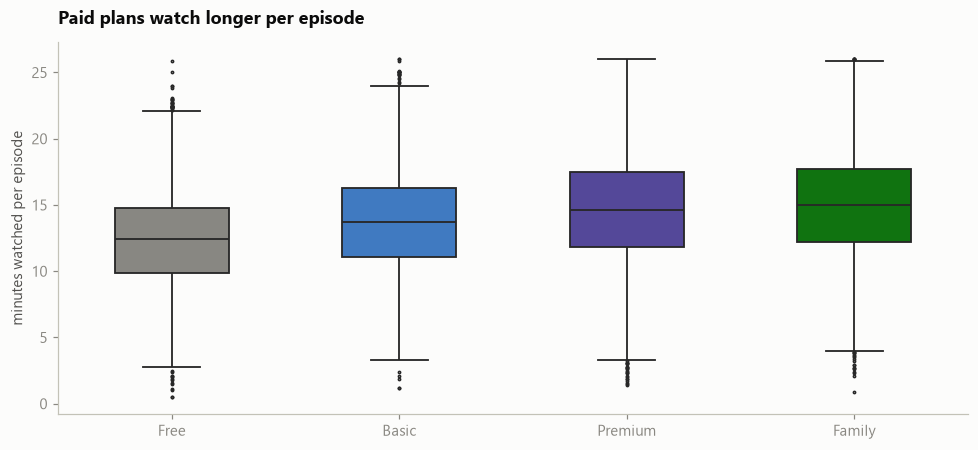

Subscription_Plan
Free       12.4
Basic      13.7
Premium    14.6
Family     15.0


In [14]:
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.boxplot(data=events, x="Subscription_Plan", y="Watch_Time_Minutes", order=PLAN_ORDER,
            palette=PLAN_COLORS, hue="Subscription_Plan", legend=False,
            fliersize=1.5, linewidth=1.2, width=0.5, ax=ax)
ax.set_title("Paid plans watch longer per episode", pad=12)
ax.set_xlabel(""); ax.set_ylabel("minutes watched per episode")
style(ax)
plt.tight_layout(); plt.show()
print(events.groupby("Subscription_Plan")["Watch_Time_Minutes"].median()
      .reindex(PLAN_ORDER).round(1).to_string())

**Takeaway.** Almost half of all viewing lands in the 19:00–23:00 window, and
the weekend-evening cells of the heatmap dominate: simulcast drops and
promotions belong on Friday–Sunday evenings, and infrastructure must be
provisioned for that peak, not the average. Mobile leads on volume but Smart TV
leads on completion — the big screen is the *finishing* device. Binge days
(3+ episodes) are a minority of user-days yet contribute an outsized share of
views, and paid plans watch measurably longer per episode — engagement and
willingness to pay travel together.

## 5. Experience quality — does buffering actually cost us?

Engineering asks for budget with anecdotes; analytics answers with the
relationship between buffering and satisfaction.

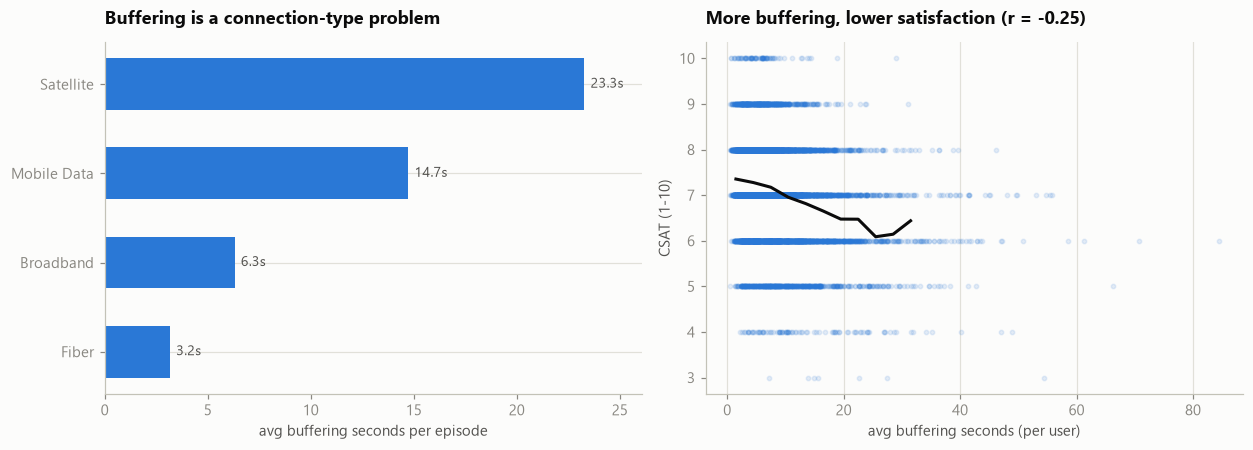

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

buf = events.groupby("Internet_Type")["Buffering_Time"].mean().sort_values()
axes[0].barh(buf.index, buf.values, color=BLUE, height=0.58)
axes[0].bar_label(axes[0].containers[0], labels=[f"{v:.1f}s" for v in buf.values],
                  padding=4, color=INK2, fontsize=9)
axes[0].set_title("Buffering is a connection-type problem", pad=12)
axes[0].set_xlabel("avg buffering seconds per episode"); axes[0].margins(x=0.12)
style(axes[0], ygrid_only=False)

u = users.merge(events.groupby("User_ID")["Buffering_Time"].mean().rename("avg_buffering"),
                left_on="User_ID", right_index=True)
axes[1].scatter(u["avg_buffering"], u["Customer_Satisfaction"], s=8, alpha=0.12, color=BLUE)
bins = pd.cut(u["avg_buffering"], np.arange(0, 36, 3))
trend = u.groupby(bins, observed=True)["Customer_Satisfaction"].mean()
centers = [iv.mid for iv in trend.index]
axes[1].plot(centers, trend.values, color=INK, lw=2)
r = u[["avg_buffering", "Customer_Satisfaction"]].corr().iloc[0, 1]
axes[1].set_title(f"More buffering, lower satisfaction (r = {r:.2f})", pad=12)
axes[1].set_xlabel("avg buffering seconds (per user)"); axes[1].set_ylabel("CSAT (1-10)")
style(axes[1])
plt.tight_layout(); plt.show()

**Takeaway.** Buffering concentrates on Satellite and Mobile Data connections —
it is an infrastructure/CDN problem with a known address, not random noise. And
it has a measurable cost: satisfaction falls steadily as average buffering
rises. Since dissatisfied users churn (section 6), a CDN or adaptive-bitrate
investment for high-latency markets has a quantifiable retention payoff.

## 6. Retention & churn — who leaves, when, and why

Retention is the economics of streaming: acquiring a subscriber costs money the
subscription only repays over months. Three questions: *which plans leak*,
*when in the lifecycle*, and *for what stated reason*.

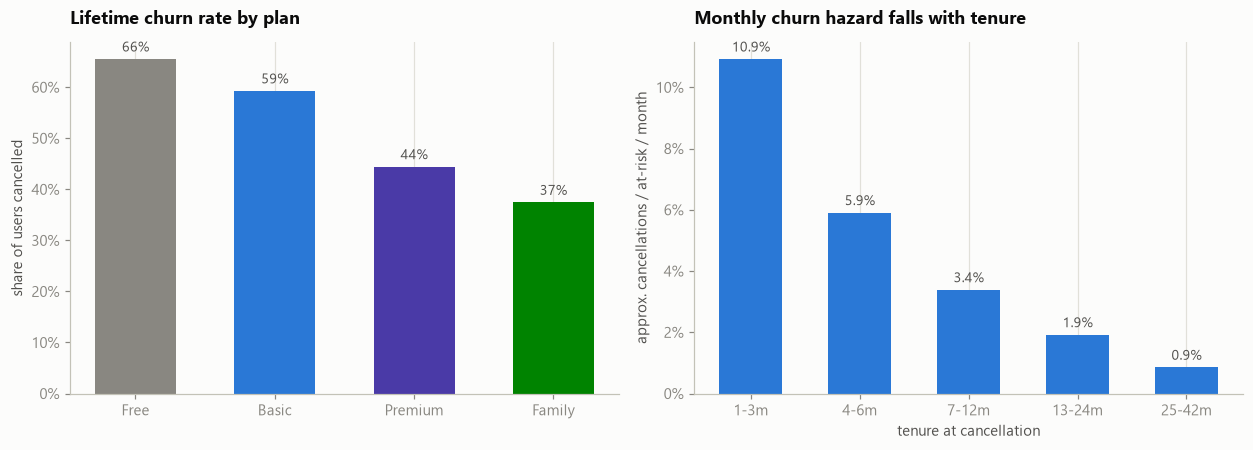

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

churn = (subs["Subscription_Status"].eq("Cancelled")
         .groupby(subs["Subscription_Plan"]).mean().reindex(PLAN_ORDER))
axes[0].bar(churn.index, churn.values, color=[PLAN_COLORS[p] for p in PLAN_ORDER], width=0.58)
axes[0].bar_label(axes[0].containers[0], labels=[f"{v:.0%}" for v in churn.values],
                  padding=3, color=INK2, fontsize=9)
axes[0].set_title("Lifetime churn rate by plan", pad=12)
axes[0].set_ylabel("share of users cancelled")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
style(axes[0])

t = subs["Membership_Tenure"]; cancelled = subs["Subscription_Status"].eq("Cancelled")
buckets = [(1, 3), (4, 6), (7, 12), (13, 24), (25, 42)]
hazard = [(cancelled & t.between(lo, hi)).sum() / max((t >= lo).sum(), 1) / (hi - lo + 1)
          for lo, hi in buckets]
labels = [f"{lo}-{hi}m" for lo, hi in buckets]
axes[1].bar(labels, hazard, color=BLUE, width=0.58)
axes[1].bar_label(axes[1].containers[0], labels=[f"{v:.1%}" for v in hazard],
                  padding=3, color=INK2, fontsize=9)
axes[1].set_title("Monthly churn hazard falls with tenure", pad=12)
axes[1].set_xlabel("tenure at cancellation"); axes[1].set_ylabel("approx. cancellations / at-risk / month")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
style(axes[1])
plt.tight_layout(); plt.show()

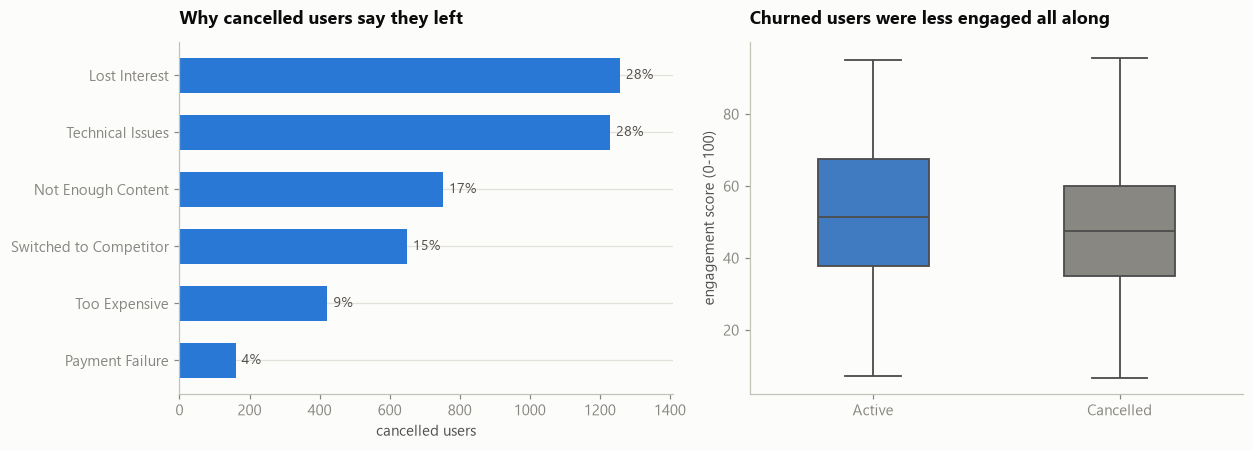

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

reasons = subs["Cancellation_Reason"].value_counts().sort_values()
axes[0].barh(reasons.index, reasons.values, color=BLUE, height=0.6)
axes[0].bar_label(axes[0].containers[0],
                  labels=[f"{v / reasons.sum():.0%}" for v in reasons.values],
                  padding=4, color=INK2, fontsize=9)
axes[0].set_title("Why cancelled users say they left", pad=12)
axes[0].set_xlabel("cancelled users"); axes[0].margins(x=0.12)
style(axes[0], ygrid_only=False)

sns.boxplot(data=users, x="Subscription_Status", y="Engagement_Score",
            order=["Active", "Cancelled"],
            palette={"Active": BLUE, "Cancelled": MUTED}, hue="Subscription_Status",
            legend=False, fliersize=1.5, linewidth=1.2, width=0.45, ax=axes[1])
axes[1].set_title("Churned users were less engaged all along", pad=12)
axes[1].set_xlabel(""); axes[1].set_ylabel("engagement score (0-100)")
style(axes[1])
plt.tight_layout(); plt.show()

**Takeaway.** Free and Basic users churn most; Family plans are the stickiest —
shared accounts create switching costs. The hazard curve is the headline: a
user's riskiest months are their **first three**, after which monthly churn
roughly quarters. Stated reasons split into price ("Too Expensive" — a
packaging/discount problem), content breadth, and "Technical Issues" — the
buffering cost from section 5 made visible. Engagement separates leavers from
stayers well before the cancel button: the onboarding window (days 0–90) is
where retention is won.

## 7. What moves together

A user-grain correlation matrix as a compass for the deeper business questions
in module 6. Computed at **user grain** — correlating event rows would let
heavy watchers dominate every coefficient (pseudo-replication).

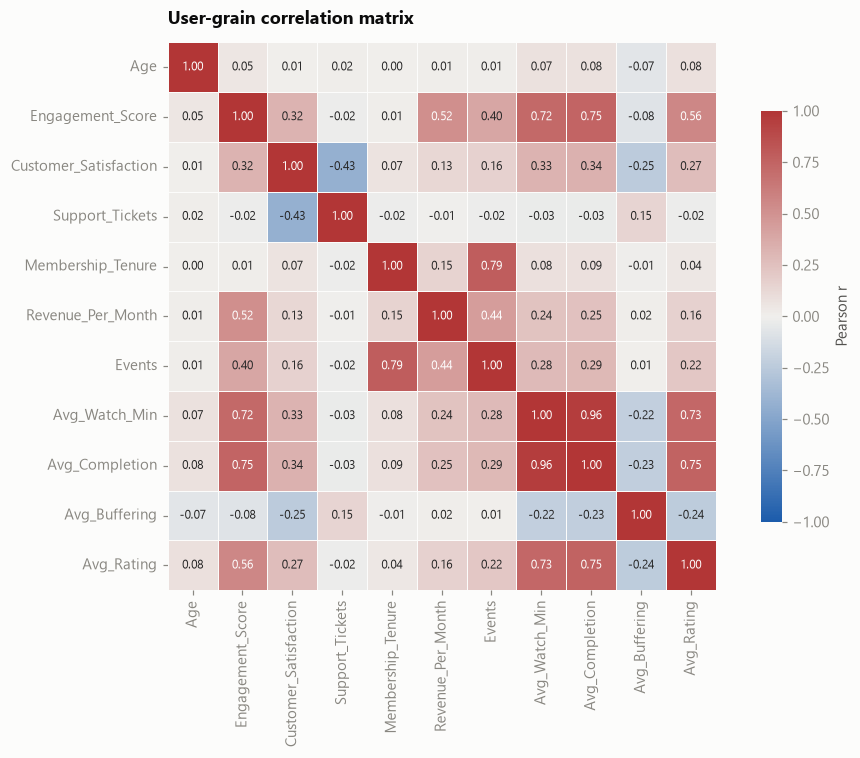

In [18]:
per_user = events.groupby("User_ID").agg(
    Events=("Event_ID", "count"),
    Avg_Watch_Min=("Watch_Time_Minutes", "mean"),
    Avg_Completion=("Completion_Percentage", "mean"),
    Avg_Buffering=("Buffering_Time", "mean"),
    Avg_Rating=("User_Rating", "mean"),
)
corr_frame = (users.set_index("User_ID")
              [["Age", "Engagement_Score", "Customer_Satisfaction", "Support_Tickets",
                "Membership_Tenure", "Revenue_Per_Month"]]
              .join(per_user))
corr = corr_frame.corr()

fig, ax = plt.subplots(figsize=(9.5, 7))
sns.heatmap(corr, cmap=DIV, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, square=True, linewidths=0.5, linecolor=SURFACE,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"}, ax=ax)
ax.set_title("User-grain correlation matrix", pad=12)
ax.grid(False)
plt.tight_layout(); plt.show()

**Takeaway.** The strong diagonal block — engagement, completion, events,
tenure — confirms a single latent "invested viewer" factor. Buffering is the
one negative thread running through satisfaction and completion. Age is nearly
orthogonal to everything: content taste, not demographics, drives behaviour
here.

## Key insights (one slide)

1. **Growth is healthy but churn-shaped**: sign-ups outpace cancellations, yet
   the first 90 days decide who stays.
2. **Free is the largest tier (~40% of users)** — conversion, not acquisition,
   is the biggest revenue lever.
3. **Shonen = ~half of watch hours**; renewals there are table stakes, while
   flat completion across genres says niche content is under-discovered, not
   unloved.
4. **Weekend evenings dominate** — schedule releases and provision
   infrastructure for that peak.
5. **Smart TV finishes what Mobile starts** — push cross-device continuation.
6. **Buffering measurably erodes satisfaction** and shows up in stated
   cancellation reasons — CDN investment has a retention ROI.
7. **Family plans are the stickiest** — shared accounts as a retention product.

**Next:** module 4 loads the star schema into SQLite and answers these
questions with 40+ interview-level SQL queries.